# Power Plant Energy Output Prediction using PyTorch ANN

### What was learned & implemented in this notebook:
1. **PyTorch Dataset & DataLoader API**:
   - Converted scaled training and testing numpy arrays to PyTorch tensors (`torch.float32`).
   - Configured mini-batching and shuffling with `TensorDataset` and `DataLoader` (batch size = 32).
2. **Artificial Neural Network (ANN) Design**:
   - Built a custom Multi-Layer Perceptron (MLP) architecture subclassing `nn.Module`.
   - Utilized `nn.Sequential` to stack dense linear layers (`nn.Linear`) and ReLU activation functions.
3. **Training & Validation Loop**:
   - Configured Mean Squared Error (MSE) loss (`nn.MSELoss`) and the Adam optimizer.
   - Handled model modes (`model.train()`, `model.eval()`) and gradient calculation controls (`torch.no_grad()`).
   - Implemented weight serialization to save the best configuration (`best_model.pt`) based on validation error.
4. **Bug Fixes**:
   - Corrected the validation phase loop which mistakenly evaluated validation loss on the `train_loader` instead of `test_loader`.

In [32]:
import pandas as pd
import numpy as np

In [33]:
df = pd.read_csv("powerplant_data.csv")

In [34]:
df
#AT - Temp
#V - vacuum
#AP - pressure
#RH - humidity
#PE - Produced energy

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


In [35]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [36]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)


In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [39]:
type(X_train_scaled)

numpy.ndarray

In [40]:
type(y_train)

pandas.core.series.Series

# Converting data to tensor

In [41]:
import torch
import torch.nn as nn
X_train_tensor = torch.tensor(X_train_scaled,dtype = torch.float32)
# Since it is another not an array so to access the values we use value keyword and view bcz 
y_train_tensor = torch.tensor(y_train.values,dtype = torch.float32).view(-1,1) 
X_test_tensor = torch.tensor(X_test_scaled,dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [42]:
type(X_train_scaled)

numpy.ndarray

In [43]:
type(y_train)
y_train.shape

(7654,)

In [44]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)


In [45]:
train_loader = DataLoader(train_dataset,batch_size = 32,shuffle = True)
test_loader =  DataLoader(test_dataset,batch_size = 32)

### Defining our ANN Model

In [49]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            #output layer
            nn.Linear(6,1),
        )
    def forward(self,x):
        return self.model(x)
            
        

In [50]:
import torch.optim as optim 
model = ANN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

### Training & Validation of DL 

In [52]:
train_loss =[]
val_loss =[]
best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs,yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_train_loss = running_loss/len(train_loader)
    train_loss.append(epoch_train_loss)

    #val
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()
        epoch_val_loss = running_val_loss/len(test_loader)
        val_loss.append(epoch_val_loss)

        print(f"epoch {epoch+1}/{epochs}==> train_loss = {epoch_train_loss}& val loss ={epoch_val_loss} ")

        if epoch_val_loss < best_val_loss:
            best_val_loss =  epoch_val_loss
            torch.save(model.state_dict(),"best_model.pt")

epoch 1/100==> train_loss = 201113.81041666667& val loss =194271.42356770832 
epoch 2/100==> train_loss = 181727.0986328125& val loss =166138.27428385417 
epoch 3/100==> train_loss = 145853.66666666666& val loss =123690.28304036458 
epoch 4/100==> train_loss = 100990.51892903647& val loss =79344.80983072917 
epoch 5/100==> train_loss = 61770.21277669271& val loss =46943.4201171875 
epoch 6/100==> train_loss = 37522.263834635414& val loss =30284.523201497395 
epoch 7/100==> train_loss = 26375.439530436197& val loss =23348.832641601562 
epoch 8/100==> train_loss = 21484.86768391927& val loss =19787.21388346354 
epoch 9/100==> train_loss = 18401.28017985026& val loss =17027.194885253906 
epoch 10/100==> train_loss = 15682.624153645833& val loss =14346.244160970053 
epoch 11/100==> train_loss = 13004.964111328125& val loss =11639.915893554688 
epoch 12/100==> train_loss = 10358.775154622395& val loss =9057.230159505209 
epoch 13/100==> train_loss = 7784.683525594076& val loss =6589.3421081

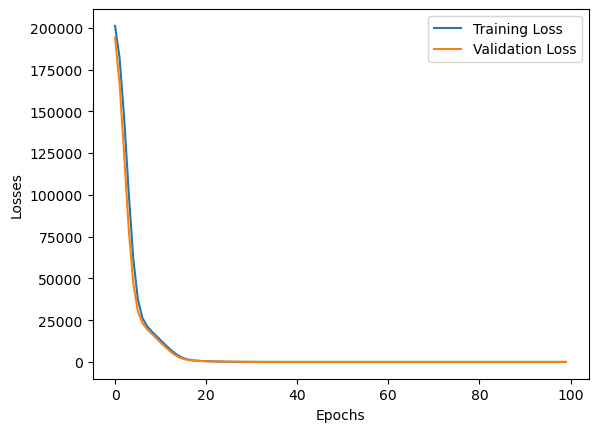

In [54]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_loss,
    "Validation Loss": val_loss
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [55]:
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = criterion(train_pred,y_train_tensor)
    test_mse_loss = criterion(test_pred,y_test_tensor)

print("Train_MSE_loss: ",train_mse_loss.item())
print("Test_MSE_loss: ",test_mse_loss.item())

Train_MSE_loss:  19.609296798706055
Test_MSE_loss:  17.999509811401367


In [58]:
from sklearn.metrics import r2_score
print("r2_score: ",r2_score(y_test,test_pred))

r2_score:  0.9370963580940863


In [60]:
predicted_df = pd.DataFrame(test_pred.numpy(),columns = ["Predicted_value"])
actual_df = pd.DataFrame(y_test.values,columns = ["Actual_value"])

pd.concat([predicted_df,actual_df],axis=1)

,Predicted_value,Actual_value
0,433.931732,433.27
1,435.757111,438.16
2,460.708069,458.42
3,476.476105,480.82
4,436.923065,441.41
...,...,...
1909,451.020172,456.70
1910,433.109924,438.04
1911,467.630951,467.80
1912,432.707672,437.14
